In [12]:
import requests

API_KEY = "MhotWNZLDCZsXdnSNXsnXje19cx7qyaH"
symbol = "MSFT"

url = f"https://financialmodelingprep.com/stable/profile?symbol={symbol}&apikey={API_KEY}"
response = requests.get(url)# Pull company profile data from Financial Modeling Prep API
data = response.json()

print(data[0]["companyName"])
print(f"Price: ${data[0]['price']}")
print(f"Market Cap: ${data[0]['marketCap']:,}")
print(f"Sector: {data[0]['sector']}")


Microsoft Corporation
Price: $381.87
Market Cap: $2,835,625,328,100
Sector: Technology


In [13]:
import pandas as pd

# Pick out the fields we care about
profile = data[0]

company_info = {
    "Company": profile["companyName"],
    "Symbol": profile["symbol"],
    "Price": profile["price"],
    "Market Cap": profile["marketCap"],
    "Sector": profile["sector"],
    "Industry": profile["industry"],
    "Beta": profile["beta"],
    "52 Week High": profile["range"].split("-")[1] if "range" in profile else "N/A",
    "52 Week Low": profile["range"].split("-")[0] if "range" in profile else "N/A",
}

df = pd.DataFrame([company_info])
df

,Company,Symbol,Price,Market Cap,Sector,Industry,Beta,52 Week High,52 Week Low
0,Microsoft Corporation,MSFT,381.87,2835625328100,Technology,Software - Infrastructure,1.108,555.45,344.79


In [14]:
def get_profile(symbol):
    url = f"https://financialmodelingprep.com/stable/profile?symbol={symbol}&apikey={API_KEY}"
    response = requests.get(url)
    profile = response.json()[0]
    return {
        "Company": profile["companyName"],
        "Symbol": profile["symbol"],
        "Price": profile["price"],
        "Market Cap": profile["marketCap"],
        "Sector": profile["sector"],
        "Industry": profile["industry"],
        "Beta": profile["beta"],
        "52 Week High": profile["range"].split("-")[1] if "range" in profile else "N/A",
        "52 Week Low": profile["range"].split("-")[0] if "range" in profile else "N/A",
    }

companies = ["AAPL", "MSFT", "TSLA"]
rows = [get_profile(symbol) for symbol in companies]
df = pd.DataFrame(rows)
df

,Company,Symbol,Price,Market Cap,Sector,Industry,Beta,52 Week High,52 Week Low
0,Apple Inc.,AAPL,247.99,3.644939e+12,Technology,Consumer Electronics,1.116,288.62,169.21
1,Microsoft Corporation,MSFT,381.87,2.835625e+12,Technology,Software - Infrastructure,1.108,555.45,344.79
2,"Tesla, Inc.",TSLA,367.96,1.380745e+12,Consumer Cyclical,Auto - Manufacturers,1.926,498.83,214.25


In [15]:
def get_metrics(symbol):
    url = f"https://financialmodelingprep.com/stable/key-metrics?symbol={symbol}&period=annual&apikey={API_KEY}"
    response = requests.get(url)
    data = response.json()
    print(f"{symbol} keys: {data[0].keys()}")
    return data

aapl_metrics = get_metrics("AAPL")

AAPL keys: dict_keys(['symbol', 'date', 'fiscalYear', 'period', 'reportedCurrency', 'marketCap', 'enterpriseValue', 'evToSales', 'evToOperatingCashFlow', 'evToFreeCashFlow', 'evToEBITDA', 'netDebtToEBITDA', 'currentRatio', 'incomeQuality', 'grahamNumber', 'grahamNetNet', 'taxBurden', 'interestBurden', 'workingCapital', 'investedCapital', 'returnOnAssets', 'operatingReturnOnAssets', 'returnOnTangibleAssets', 'returnOnEquity', 'returnOnInvestedCapital', 'returnOnCapitalEmployed', 'earningsYield', 'freeCashFlowYield', 'capexToOperatingCashFlow', 'capexToDepreciation', 'capexToRevenue', 'salesGeneralAndAdministrativeToRevenue', 'researchAndDevelopementToRevenue', 'stockBasedCompensationToRevenue', 'intangiblesToTotalAssets', 'averageReceivables', 'averagePayables', 'averageInventory', 'daysOfSalesOutstanding', 'daysOfPayablesOutstanding', 'daysOfInventoryOutstanding', 'operatingCycle', 'cashConversionCycle', 'freeCashFlowToEquity', 'freeCashFlowToFirm', 'tangibleAssetValue', 'netCurrentAss

In [16]:
def get_metrics(symbol):
    url = f"https://financialmodelingprep.com/stable/key-metrics?symbol={symbol}&period=annual&apikey={API_KEY}"
    response = requests.get(url)
    latest = response.json()[0]  # Most recent year
    return {
        "Symbol": symbol,
        "Year": latest["fiscalYear"],
        "Market Cap": latest["marketCap"],
        "EV/EBITDA": latest["evToEBITDA"],
        "Current Ratio": latest["currentRatio"],
        "Return on Equity": latest["returnOnEquity"],
        "Return on Invested Capital": latest["returnOnInvestedCapital"],
        "Earnings Yield": latest["earningsYield"],
        "FCF Yield": latest["freeCashFlowYield"],
        "Net Debt/EBITDA": latest["netDebtToEBITDA"],
    }

companies = ["AAPL", "MSFT", "GOOGL"]
rows = [get_metrics(symbol) for symbol in companies]
metrics_df = pd.DataFrame(rows)
metrics_df

,Symbol,Year,Market Cap,EV/EBITDA,Current Ratio,Return on Equity,Return on Invested Capital,Earnings Yield,FCF Yield,Net Debt/EBITDA
0,AAPL,2025,3818743810000,26.969935,0.893293,1.519130,0.519684,0.029332,0.025864,0.529285
1,MSFT,2025,3697248530000,23.595608,1.353446,0.296472,0.216333,0.027543,0.019369,0.511610
2,GOOGL,2025,3792308000000,21.302469,2.005334,0.318279,0.218234,0.034852,0.019320,0.229643


In [17]:
def get_financials(symbol):
    url = f"https://financialmodelingprep.com/stable/income-statement?symbol={symbol}&period=annual&apikey={API_KEY}"
    response = requests.get(url)
    data = response.json()
    print(f"{symbol} keys: {data[0].keys()}")
    return data

aapl_financials = get_financials("AAPL")

AAPL keys: dict_keys(['date', 'symbol', 'reportedCurrency', 'cik', 'filingDate', 'acceptedDate', 'fiscalYear', 'period', 'revenue', 'costOfRevenue', 'grossProfit', 'researchAndDevelopmentExpenses', 'generalAndAdministrativeExpenses', 'sellingAndMarketingExpenses', 'sellingGeneralAndAdministrativeExpenses', 'otherExpenses', 'operatingExpenses', 'costAndExpenses', 'netInterestIncome', 'interestIncome', 'interestExpense', 'depreciationAndAmortization', 'ebitda', 'ebit', 'nonOperatingIncomeExcludingInterest', 'operatingIncome', 'totalOtherIncomeExpensesNet', 'incomeBeforeTax', 'incomeTaxExpense', 'netIncomeFromContinuingOperations', 'netIncomeFromDiscontinuedOperations', 'otherAdjustmentsToNetIncome', 'netIncome', 'netIncomeDeductions', 'bottomLineNetIncome', 'eps', 'epsDiluted', 'weightedAverageShsOut', 'weightedAverageShsOutDil'])


In [18]:
def get_financials(symbol):
    url = f"https://financialmodelingprep.com/stable/income-statement?symbol={symbol}&period=annual&apikey={API_KEY}"
    response = requests.get(url)
    latest = response.json()[0]
    revenue = latest["revenue"]
    return {
        "Symbol": symbol,
        "Year": latest["fiscalYear"],
        "Revenue": revenue,
        "Gross Profit": latest["grossProfit"],
        "Operating Income": latest["operatingIncome"],
        "Net Income": latest["netIncome"],
        "EPS": latest["epsDiluted"],
        "Gross Margin": round(latest["grossProfit"] / revenue * 100, 2),
        "Operating Margin": round(latest["operatingIncome"] / revenue * 100, 2),
        "Net Margin": round(latest["netIncome"] / revenue * 100, 2),
    }

companies = ["AAPL", "MSFT", "GOOGL"]
rows = [get_financials(symbol) for symbol in companies]
financials_df = pd.DataFrame(rows)
financials_df

,Symbol,Year,Revenue,Gross Profit,Operating Income,Net Income,EPS,Gross Margin,Operating Margin,Net Margin
0,AAPL,2025,416161000000,195201000000,133050000000,112010000000,7.46,46.91,31.97,26.92
1,MSFT,2025,281724000000,193893000000,128528000000,101832000000,13.64,68.82,45.62,36.15
2,GOOGL,2025,402963000000,240428000000,129166000000,132170000000,10.81,59.67,32.05,32.80


In [19]:
import requests
import pandas as pd

# API_KEY is available in the kernel state

def analyze_company(symbol): # Corrected function signature
    # Helper function to make API calls, as fmp_get was not defined
    def _fmp_get(endpoint_name, s):
        url = f"https://financialmodelingprep.com/stable/{endpoint_name}?symbol={s}&period=annual&apikey={API_KEY}"
        response = requests.get(url)
        # Check if the response contains data, otherwise return an empty dict to avoid IndexError
        if response.json():
            return response.json()[0]
        else:
            return {} # Return empty dictionary if no data

    # The premature return statement is removed.
    profile = _fmp_get("profile", symbol)
    metrics = _fmp_get("key-metrics", symbol)
    financials = _fmp_get("income-statement", symbol)

    # Add checks for empty dictionaries if API calls failed
    if not profile or not metrics or not financials:
        print(f"Could not retrieve full data for {symbol}. Skipping.")
        return None # Return None if data is incomplete

    revenue = financials.get("revenue") # Use .get() for safer access

    # Handle cases where revenue might be missing or zero to prevent division by zero
    gross_profit = financials.get("grossProfit", 0)
    operating_income = financials.get("operatingIncome", 0)
    net_income = financials.get("netIncome", 0)

    gross_margin_pct = round(gross_profit / revenue * 100, 2) if revenue else 0
    operating_margin_pct = round(operating_income / revenue * 100, 2) if revenue else 0
    net_margin_pct = round(net_income / revenue * 100, 2) if revenue else 0

    return {
        "Company": profile.get("companyName"),
        "Symbol": symbol,
        "Sector": profile.get("sector"),
        "Price": profile.get("price"),
        "Market Cap": metrics.get("marketCap"),
        "Revenue": revenue,
        "Net Income": net_income,
        "EPS": financials.get("epsDiluted"),
        "Gross Margin %": gross_margin_pct,
        "Operating Margin %": operating_margin_pct,
        "Net Margin %": net_margin_pct,
        "ROE": metrics.get("returnOnEquity"),
        "ROIC": metrics.get("returnOnInvestedCapital"),
        "EV/EBITDA": metrics.get("evToEBITDA"),
        "Earnings Yield": metrics.get("earningsYield"),
        "Current Ratio": metrics.get("currentRatio"),
        "Net Debt/EBITDA": metrics.get("netDebtToEBITDA"),
    }

companies = ["AAPL", "F", "UNH"]
# Filter out None results if some API calls failed for a company
rows = [analyze_company(s) for s in companies]
rows = [row for row in rows if row is not None] # Filter out failed calls

master_df = pd.DataFrame(rows)
master_df

,Company,Symbol,Sector,Price,Market Cap,Revenue,Net Income,EPS,Gross Margin %,Operating Margin %,Net Margin %,ROE,ROIC,EV/EBITDA,Earnings Yield,Current Ratio,Net Debt/EBITDA
0,Apple Inc.,AAPL,Technology,247.990,3818743810000,416161000000,112010000000,7.46,46.91,31.97,26.92,1.519130,0.519684,26.969935,0.029332,0.893293,0.529285
1,Ford Motor Company,F,Consumer Cyclical,11.515,52204480000,187267000000,-8182000000,-2.06,12.18,1.35,-4.37,-0.227581,0.007525,23.035239,-0.156730,1.074828,16.912982
2,UnitedHealth Group Incorporated,UNH,Healthcare,275.590,300400100000,447567000000,12056000000,13.23,18.53,4.24,2.69,0.128105,0.082316,15.369649,0.040133,0.788376,2.342758


In [20]:
from google.colab import ai

# Convert your dataframe to a string the LLM can read
data_text = master_df.to_string()

prompt = f"""You are a senior financial analyst writing a report for an investor.

Here is financial data for several companies:

{data_text}

For each company, evaluate:
1. Profitability (margins, ROE, ROIC)
2. Valuation (EV/EBITDA, Earnings Yield)
3. Financial health (Current Ratio, Net Debt/EBITDA)

Then rank the companies from strongest to weakest overall. For each ranking, cite the specific numbers that support your reasoning. Flag any red flags or standout strengths.

Weight these factors in order of importance:
1. Profitability (margins, ROE, ROIC) - most important
2. Financial health (debt levels, current ratio) - second
3. Valuation (EV/EBITDA, earnings yield) - third

A highly profitable company with high debt is riskier than a moderately profitable company with no debt. A cheap stock that is unprofitable is not a good value.

Output format:
- One short paragraph per company summarizing its overall picture (strengths, weaknesses, red flags) with specific numbers inline
- Then a final ranking section that directly compares the companies against each other, explaining why #1 beats #2 and #2 beats #3
- Be concise. No category-by-category breakdown per company.

Format rules:
- No letter formatting, greetings, or dates
- Use a direct, professional tone
- Start with the analysis immediately
- Present numbers as percentages where appropriate (e.g., 29.65% not 0.2965)"""

response = ai.generate_text(prompt)
print(response)

**Apple Inc. (AAPL)**
Apple demonstrates exceptional profitability, with a Gross Margin of 46.91%, Operating Margin of 31.97%, and a Net Margin of 26.92%. Its Return on Equity (ROE) is an outstanding 151.91%, and Return on Invested Capital (ROIC) is an impressive 51.97%, indicating highly efficient capital utilization. Financially, Apple is robust with a very low Net Debt/EBITDA of 0.53x, a significant strength. Its Current Ratio of 0.89 is a yellow flag, suggesting potential short-term liquidity tightness, though often managed by strong cash flows in its industry. However, the company commands a premium valuation, reflected in its high EV/EBITDA of 26.97x and a relatively low Earnings Yield of 2.93%.

**Ford Motor Company (F)**
Ford Motor Company exhibits severe profitability challenges, evidenced by a low Gross Margin of 12.18%, an anemic Operating Margin of 1.35%, and a negative Net Margin of -4.37%. Consequently, both its ROE of -22.76% and ROIC of 0.75% are extremely poor. The mos

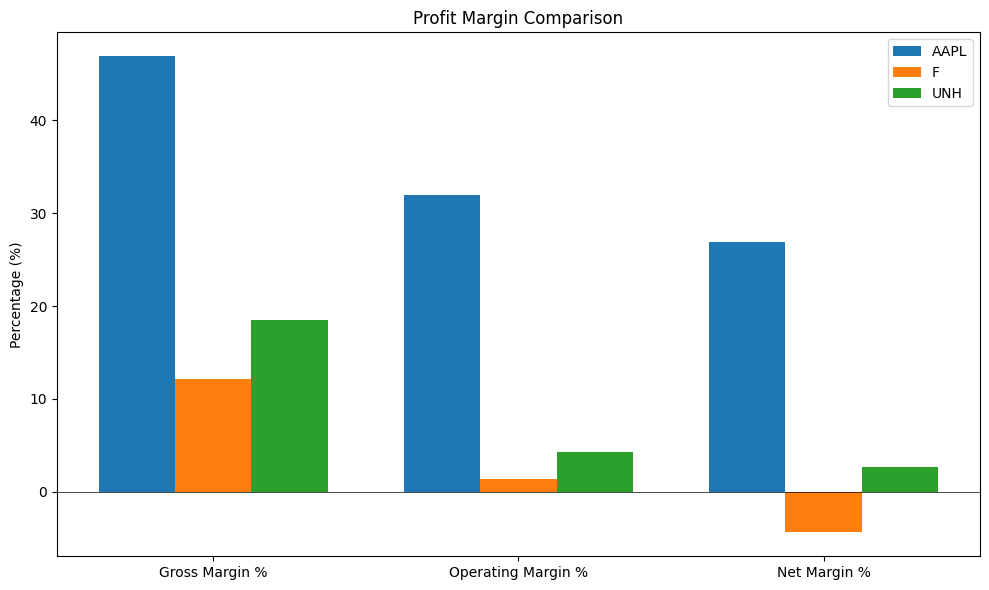

In [21]:
import matplotlib.pyplot as plt

# Compare margins across companies
categories = ["Gross Margin %", "Operating Margin %", "Net Margin %"]
x = range(len(categories))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))

for i, row in master_df.iterrows():
    values = [row[cat] for cat in categories]
    offset = (i - 1) * width
    ax.bar([p + offset for p in x], values, width, label=row["Symbol"])

ax.set_ylabel("Percentage (%)")
ax.set_title("Profit Margin Comparison")
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.legend()
ax.axhline(y=0, color="black", linewidth=0.5)

plt.tight_layout()
plt.show()

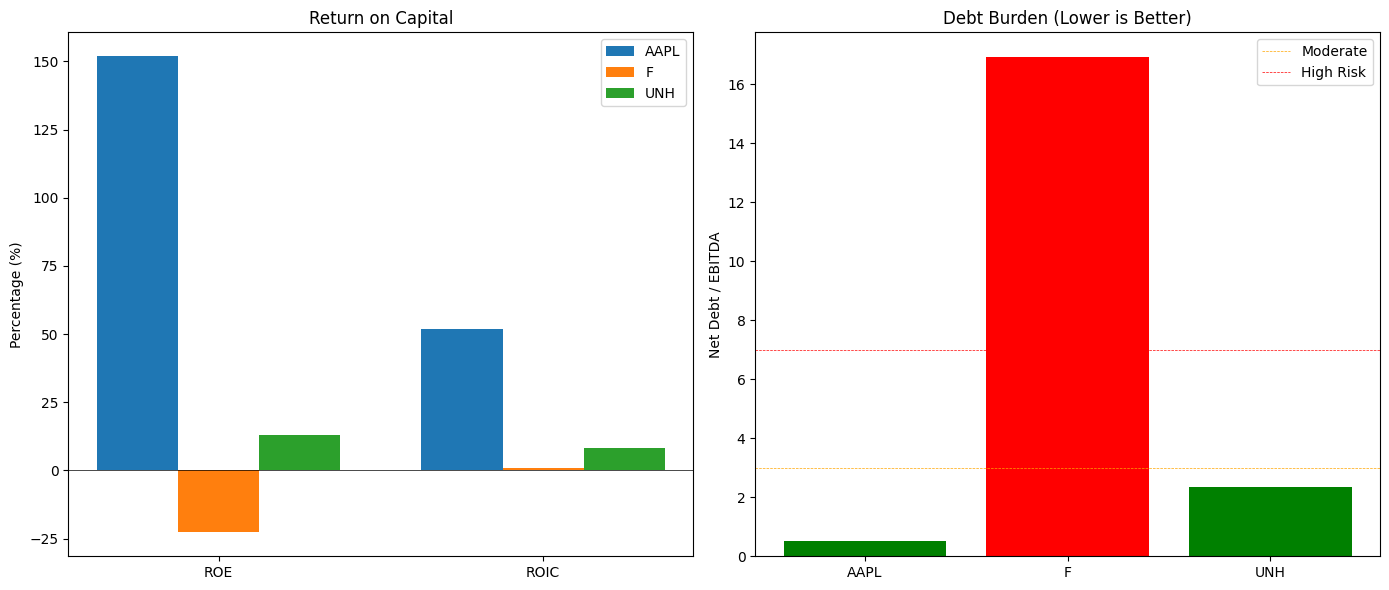

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Chart 1: ROE and ROIC
metrics = ["ROE", "ROIC"]
x = range(len(metrics))
for i, row in master_df.iterrows():
    values = [row[m] * 100 for m in metrics]  # Convert to percentages
    offset = (i - 1) * width
    axes[0].bar([p + offset for p in x], values, width, label=row["Symbol"])

axes[0].set_ylabel("Percentage (%)")
axes[0].set_title("Return on Capital")
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics)
axes[0].legend()
axes[0].axhline(y=0, color="black", linewidth=0.5)

# Chart 2: Net Debt/EBITDA
symbols = master_df["Symbol"].tolist()
debt_values = master_df["Net Debt/EBITDA"].tolist()
colors = ["green" if v < 3 else "orange" if v < 7 else "red" for v in debt_values]

axes[1].bar(symbols, debt_values, color=colors)
axes[1].set_ylabel("Net Debt / EBITDA")
axes[1].set_title("Debt Burden (Lower is Better)")
axes[1].axhline(y=3, color="orange", linewidth=0.5, linestyle="--", label="Moderate")
axes[1].axhline(y=7, color="red", linewidth=0.5, linestyle="--", label="High Risk")
axes[1].legend()

plt.tight_layout()
plt.show()

Pulling financial data...

=== Financial Comparison ===



,Company,Symbol,Sector,Price,Market Cap,Revenue,Net Income,EPS,Gross Margin %,Operating Margin %,Net Margin %,ROE,ROIC,EV/EBITDA,Earnings Yield,Current Ratio,Net Debt/EBITDA
0,Apple Inc.,AAPL,Technology,247.99,3818743810000,416161000000,112010000000,7.46,46.91,31.97,26.92,1.51913,0.519684,26.969935,0.029332,0.893293,0.529285


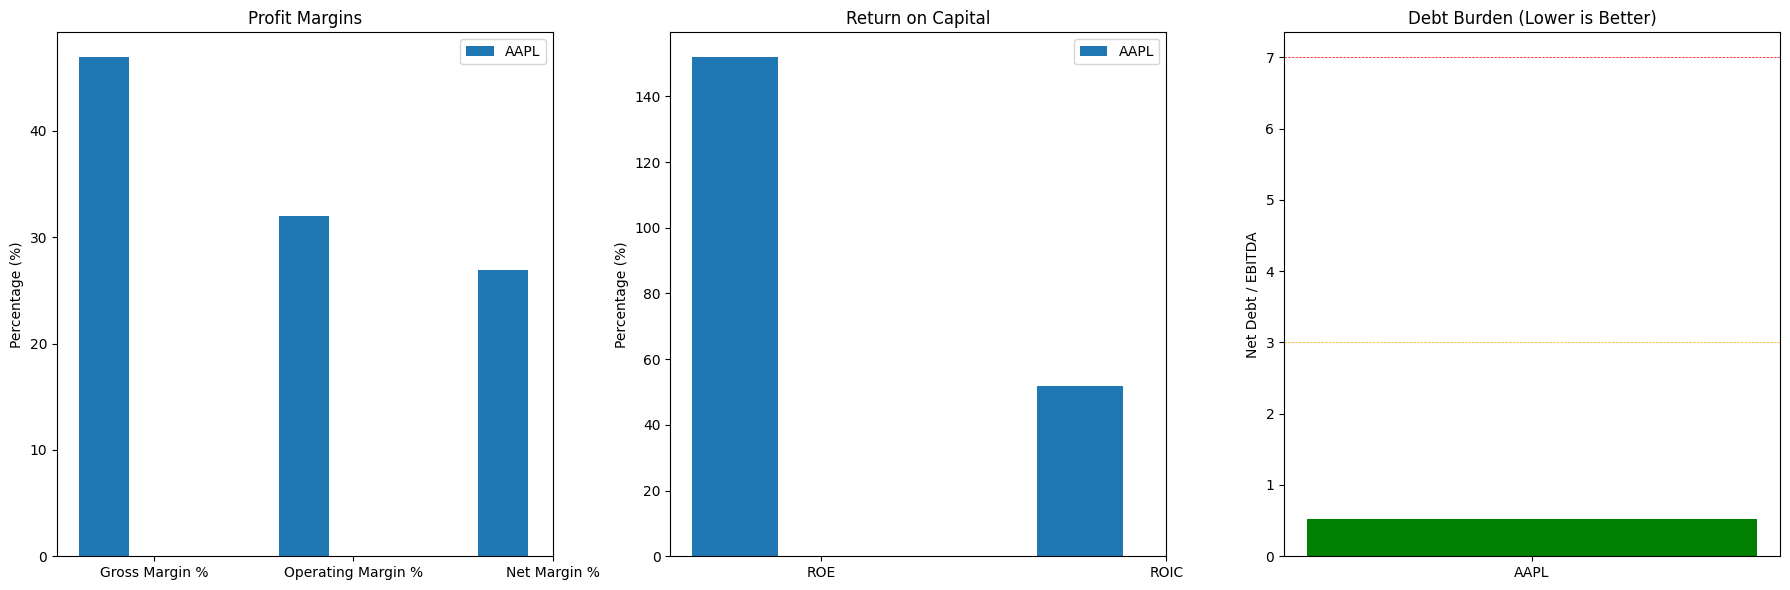


=== AI Analysis ===

Apple Inc. demonstrates exceptional profitability, boasting gross margins of 46.91%, operating margins of 31.97%, and net margins of 26.92%. Its capital efficiency is outstanding, with an ROIC of 51.97% and a very high ROE of 151.91%, reflecting strong competitive advantages and effective capital deployment. Financially, the company maintains a healthy debt profile with a low Net Debt/EBITDA of 0.53x, but its current ratio of 0.89 indicates potential short-term liquidity management. From a valuation standpoint, Apple is priced at a premium, with an EV/EBITDA of 26.97x and an earnings yield of 2.93%, suggesting high market expectations for its sustained performance.

**Ranking Section**
With only one company provided, a comparative ranking is not possible. Based on the analysis, Apple Inc. exhibits elite profitability and capital efficiency, strong debt management, but trades at a premium valuation.


In [25]:
def full_analysis(companies):
    # 1. Pull data
    print("Pulling financial data...")
    rows = [analyze_company(s) for s in companies]
    rows = [r for r in rows if r is not None]
    df = pd.DataFrame(rows)

    # 2. Display table
    print("\n=== Financial Comparison ===\n")
    display(df)

    # 3. Charts
    categories = ["Gross Margin %", "Operating Margin %", "Net Margin %"]
    x = range(len(categories))
    width = 0.25

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    # Margins chart
    for i, row in df.iterrows():
        values = [row[cat] for cat in categories]
        offset = (i - 1) * width
        axes[0].bar([p + offset for p in x], values, width, label=row["Symbol"])
    axes[0].set_ylabel("Percentage (%)")
    axes[0].set_title("Profit Margins")
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(categories)
    axes[0].legend()
    axes[0].axhline(y=0, color="black", linewidth=0.5)

    # Return on capital chart
    metrics = ["ROE", "ROIC"]
    x2 = range(len(metrics))
    for i, row in df.iterrows():
        values = [row[m] * 100 for m in metrics]
        offset = (i - 1) * width
        axes[1].bar([p + offset for p in x2], values, width, label=row["Symbol"])
    axes[1].set_ylabel("Percentage (%)")
    axes[1].set_title("Return on Capital")
    axes[1].set_xticks(x2)
    axes[1].set_xticklabels(metrics)
    axes[1].legend()
    axes[1].axhline(y=0, color="black", linewidth=0.5)

    # Debt chart
    symbols = df["Symbol"].tolist()
    debt_values = df["Net Debt/EBITDA"].tolist()
    colors = ["green" if v < 3 else "orange" if v < 7 else "red" for v in debt_values]
    axes[2].bar(symbols, debt_values, color=colors)
    axes[2].set_ylabel("Net Debt / EBITDA")
    axes[2].set_title("Debt Burden (Lower is Better)")
    axes[2].axhline(y=3, color="orange", linewidth=0.5, linestyle="--")
    axes[2].axhline(y=7, color="red", linewidth=0.5, linestyle="--")

    plt.tight_layout()
    plt.show()

    # 4. LLM Analysis
    print("\n=== AI Analysis ===\n")
    data_text = df.to_string()

    prompt = f"""You are a financial analyst. Here is financial data for several companies:

{data_text}

Weight these factors in order of importance:
1. Profitability (margins, ROE, ROIC) - most important
2. Financial health (debt levels, current ratio) - second
3. Valuation (EV/EBITDA, earnings yield) - third

A highly profitable company with high debt is riskier than a moderately profitable company with no debt. A cheap stock that is unprofitable is not a good value.

Output format:
- One short paragraph per company summarizing its overall picture (strengths, weaknesses, red flags) with specific numbers inline
- Then a final ranking section that directly compares the companies against each other, explaining why #1 beats #2 and #2 beats #3
- Be concise. No category-by-category breakdown per company.
- Present numbers as percentages where appropriate (e.g., 29.65% not 0.2965)
- No letter formatting, greetings, or dates"""

    response = ai.generate_text(prompt)
    print(response)

# Run it
full_analysis(["AAPL"])